# Exploratory Data Analysis

This notebook analyses regular unleaded petrol prices across the Perth metropolitan area from January to June 2026.

The analysis focuses on:
- overall price trends
- weekday price patterns
- differences between brands
- differences between suburbs
- stations that are consistently cheaper than the daily market average

In [145]:
import pandas as pd
import math
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Load the cleaned dataset

The cleaned Perth ULP dataset is loaded from the processed data directory. The date column is parsed as a datetime value for time-based analysis.

In [146]:
processed_path = Path(
    "../data/processed/perth_ulp_2026_01_to_06.csv"
)

df = pd.read_csv(
    processed_path,
    parse_dates=["date"]
)

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())

df.head()

Shape: (81123, 18)
Date range: 2026-01-01 00:00:00 to 2026-06-30 00:00:00


,date,station_name,brand,fuel_type,price_cpl,address,suburb,postcode,area,region,source_file,station_id,year,month,month_name,day_of_week,day_number,is_weekend
0,2026-01-01,7-Eleven Alkimos,7-Eleven,ULP,169.9,10 Carlsbad Prom,ALKIMOS,6038,North of River,Metro,fuelwatch_2026_01.csv,7-eleven alkimos_10 carlsbad prom_alkimos,2026,1,January,Thursday,3,False
1,2026-01-01,7-Eleven Ascot,7-Eleven,ULP,179.9,194 Great Eastern Hwy,ASCOT,6104,South of River,Metro,fuelwatch_2026_01.csv,7-eleven ascot_194 great eastern hwy_ascot,2026,1,January,Thursday,3,False
2,2026-01-01,7-Eleven Balcatta,7-Eleven,ULP,179.9,174 Balcatta Rd,BALCATTA,6021,North of River,Metro,fuelwatch_2026_01.csv,7-eleven balcatta_174 balcatta rd_balcatta,2026,1,January,Thursday,3,False
3,2026-01-01,7-Eleven Baldivis,7-Eleven,ULP,179.9,370 Baldivis Rd,BALDIVIS,6171,South of River,Metro,fuelwatch_2026_01.csv,7-eleven baldivis_370 baldivis rd_baldivis,2026,1,January,Thursday,3,False
4,2026-01-01,7-Eleven Balga,7-Eleven,ULP,179.9,102 Princess Rd,BALGA,6061,North of River,Metro,fuelwatch_2026_01.csv,7-eleven balga_102 princess rd_balga,2026,1,January,Thursday,3,False


## 2. Review the analysis dataset
A final structural check is performed before beginning the exploratory analysis.

In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81123 entries, 0 to 81122
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          81123 non-null  datetime64[ns]
 1   station_name  81123 non-null  object        
 2   brand         81123 non-null  object        
 3   fuel_type     81123 non-null  object        
 4   price_cpl     81123 non-null  float64       
 5   address       81123 non-null  object        
 6   suburb        81123 non-null  object        
 7   postcode      81123 non-null  int64         
 8   area          81123 non-null  object        
 9   region        81123 non-null  object        
 10  source_file   81123 non-null  object        
 11  station_id    81123 non-null  object        
 12  year          81123 non-null  int64         
 13  month         81123 non-null  int64         
 14  month_name    81123 non-null  object        
 15  day_of_week   81123 non-null  object

In [148]:
print("Unique stations:", df["station_id"].nunique())
print("Unique suburbs:", df["suburb"].nunique())
print("Unique brands:", df["brand"].nunique())

df["price_cpl"].describe()

Unique stations: 461


Unique suburbs: 202
Unique brands: 24


count    81123.000000
mean       183.849267
std         28.945487
min        136.500000
25%        163.900000
50%        173.900000
75%        196.900000
max        275.900000
Name: price_cpl, dtype: float64

## 3. Analyse daily fuel price trends

Daily summary statistics are calculated to examine how Perth ULP prices changed over the study period.

In [149]:
daily_price = (
    df.groupby("date", as_index=False)
    .agg(
        average_price=("price_cpl", "mean"),
        minimum_price=("price_cpl", "min"),
        maximum_price=("price_cpl", "max"),
        median_price=("price_cpl", "median"),
        station_count=("station_id", "nunique")
    )
)

daily_price.head()

,date,average_price,minimum_price,maximum_price,median_price,station_count
0,2026-01-01,175.844789,148.3,199.9,175.9,451
1,2026-01-02,170.621729,148.0,199.9,173.9,451
2,2026-01-03,168.187361,148.0,199.9,169.9,451
3,2026-01-04,167.018847,148.0,199.9,167.9,451
4,2026-01-05,165.721508,148.0,190.9,165.9,451


### Daily average ULP price

The line chart shows the movement of average ULP prices across Perth over time.

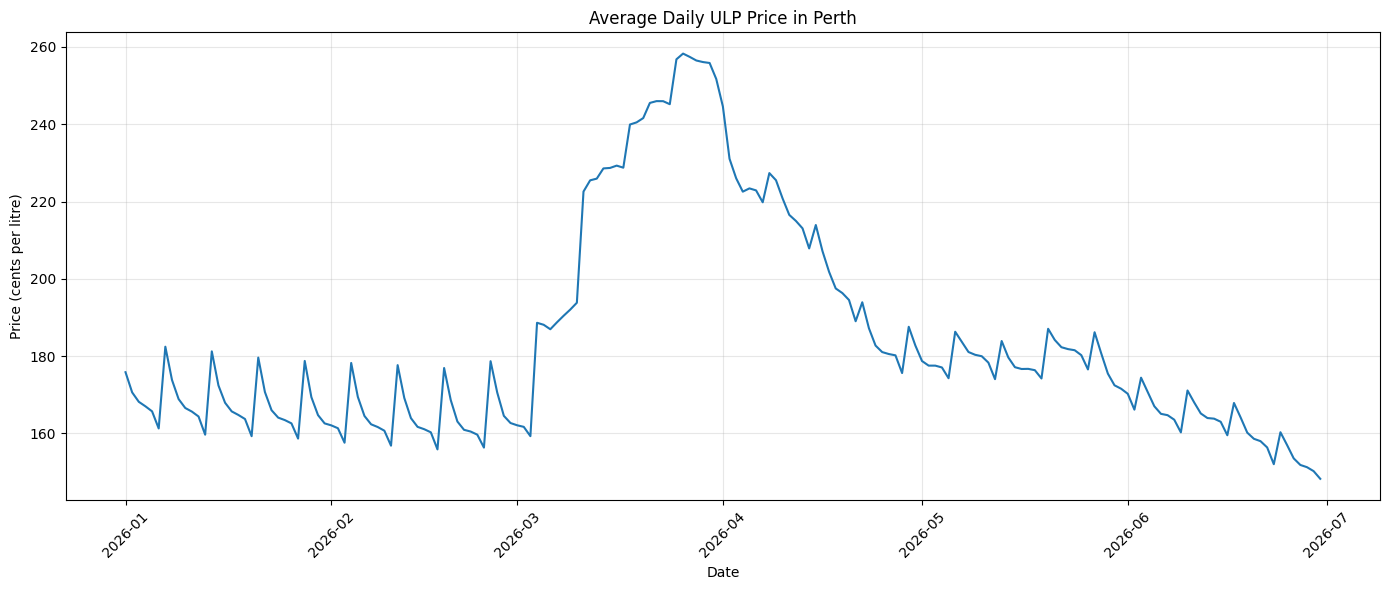

In [150]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_price["date"],
    daily_price["average_price"]
)

plt.title("Average Daily ULP Price in Perth")
plt.xlabel("Date")
plt.ylabel("Price (cents per litre)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Daily price range

The minimum and maximum daily prices are compared with the daily average to illustrate the price variation available to consumers.

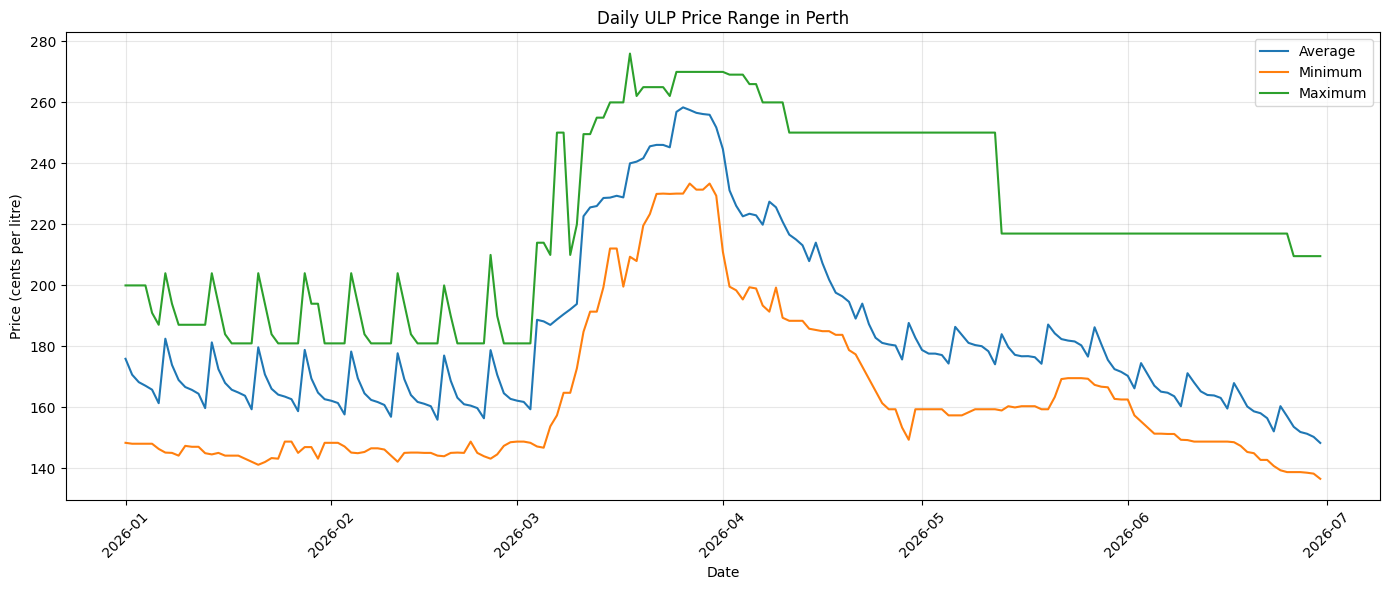

In [151]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_price["date"],
    daily_price["average_price"],
    label="Average"
)

plt.plot(
    daily_price["date"],
    daily_price["minimum_price"],
    label="Minimum"
)

plt.plot(
    daily_price["date"],
    daily_price["maximum_price"],
    label="Maximum"
)

plt.title("Daily ULP Price Range in Perth")
plt.xlabel("Date")
plt.ylabel("Price (cents per litre)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Lowest and highest average-price days

The days with the lowest and highest average ULP prices are identified.

In [152]:
lowest_day = daily_price.loc[
    daily_price["average_price"].idxmin()
]

highest_day = daily_price.loc[
    daily_price["average_price"].idxmax()
]

print("Lowest average-price day:")
print(lowest_day)

print("\nHighest average-price day:")
print(highest_day)

Lowest average-price day:
date             2026-06-30 00:00:00
average_price             148.263252
minimum_price                  136.5
maximum_price                  209.5
median_price                   147.9
station_count                    449
Name: 180, dtype: object

Highest average-price day:
date             2026-03-26 00:00:00
average_price             258.268973
minimum_price                  230.0
maximum_price                  269.9
median_price                   259.9
station_count                    448
Name: 84, dtype: object


## 4. Analyse weekday price patterns

Average ULP prices are compared across the days of the week to identify whether certain weekdays had lower or higher average prices.

In [153]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_price = (
    df.groupby("day_of_week", as_index=False)
    .agg(
        average_price=("price_cpl", "mean"),
        median_price=("price_cpl", "median"),
        minimum_price=("price_cpl", "min"),
        maximum_price=("price_cpl", "max"),
        observations=("price_cpl", "size")
    )
)

weekday_price["day_of_week"] = pd.Categorical(
    weekday_price["day_of_week"],
    categories=weekday_order,
    ordered=True
)

weekday_price = weekday_price.sort_values("day_of_week")

weekday_price

,day_of_week,average_price,median_price,minimum_price,maximum_price,observations
1,Monday,181.105142,169.9,138.2,269.9,11650
5,Tuesday,177.745547,167.7,136.5,269.9,11656
6,Wednesday,193.035984,189.9,139.3,275.9,11205
4,Thursday,187.454804,179.9,138.7,269.9,11656
0,Friday,183.755130,173.9,138.7,269.9,11656
2,Saturday,182.291086,169.9,138.7,269.9,11656
3,Sunday,181.909224,169.9,138.5,269.9,11644


### Average ULP price by weekday

The bar chart compares average ULP prices across each day of the week.

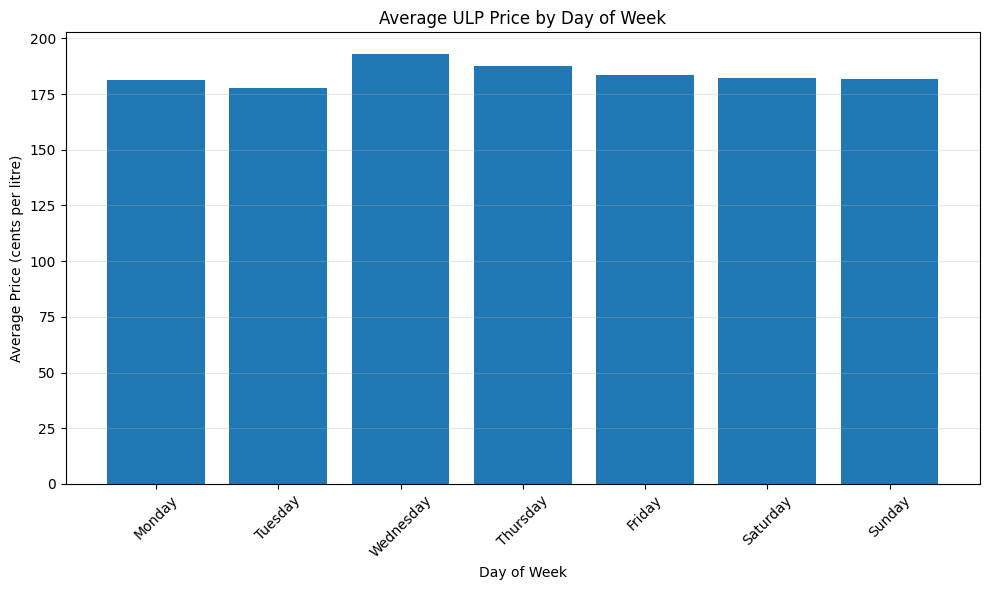

In [154]:
plt.figure(figsize=(10, 6))

plt.bar(
    weekday_price["day_of_week"],
    weekday_price["average_price"]
)

plt.title("Average ULP Price by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Price (cents per litre)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### Cheapest and most expensive weekdays

The weekdays with the lowest and highest average ULP prices are identified.

In [155]:
cheapest_weekday = weekday_price.loc[
    weekday_price["average_price"].idxmin()
]

most_expensive_weekday = weekday_price.loc[
    weekday_price["average_price"].idxmax()
]

print("Cheapest weekday:")
print(cheapest_weekday)

print("\nMost expensive weekday:")
print(most_expensive_weekday)

Cheapest weekday:
day_of_week         Tuesday
average_price    177.745547
median_price          167.7
minimum_price         136.5
maximum_price         269.9
observations          11656
Name: 5, dtype: object

Most expensive weekday:
day_of_week       Wednesday
average_price    193.035984
median_price          189.9
minimum_price         139.3
maximum_price         275.9
observations          11205
Name: 6, dtype: object


### Estimated saving by choosing the cheapest weekday

The potential saving for a 60-litre fuel tank is calculated using the difference between the cheapest and most expensive average weekday prices.

In [156]:
price_difference_cpl = (
    most_expensive_weekday["average_price"]
    - cheapest_weekday["average_price"]
)

tank_size_litres = 60

estimated_saving = (
    price_difference_cpl * tank_size_litres
) / 100

print(
    f"Average price difference: "
    f"{price_difference_cpl:.2f} cents per litre"
)

print(
    f"Estimated saving for a {tank_size_litres}L tank: "
    f"${estimated_saving:.2f}"
)

Average price difference: 15.29 cents per litre
Estimated saving for a 60L tank: $9.17


### Key findings

The analysis shows that Tuesday had the lowest average ULP price,
while Wednesday had the highest average price during the study
period.

The average difference was approximately 15.29 cents per litre,
equivalent to around $9.17 for a 60-litre tank.

## 5. Compare fuel prices by brand

Average ULP prices are compared across fuel brands to identify which brands were generally cheaper or more expensive during the study period.

In [157]:
brand_price = (
    df.groupby("brand", as_index=False)
    .agg(
        average_price=("price_cpl", "mean"),
        median_price=("price_cpl", "median"),
        minimum_price=("price_cpl", "min"),
        maximum_price=("price_cpl", "max"),
        observations=("price_cpl", "size"),
        station_count=("station_id", "nunique")
    )
)

brand_price = brand_price[
    brand_price["observations"] >= 100 # filter brands who have small amount of observations
].sort_values("average_price")

brand_price

,brand,average_price,median_price,minimum_price,maximum_price,observations,station_count
8,Costco,168.534254,156.7,138.7,246.7,362,2
6,Burk,171.276658,160.3,137.3,253.3,1568,10
14,OMG Caltex,172.718261,163.9,153.9,249.9,230,3
10,FastFuel 24/7,173.557459,162.9,145.9,246.9,181,1
19,Solo,174.278307,164.4,136.5,275.9,378,3
3,Atlas,174.713047,162.9,140.7,255.9,2353,14
12,Liberty,175.619912,165.2,141.3,259.5,1808,10
20,UGO,175.693370,163.9,145.9,243.9,181,1
23,X Convenience,176.395028,159.5,143.5,259.5,181,1
22,Vibe,176.992968,169.2,137.9,259.7,5973,33


### Cheapest fuel brands

The ten brands with the lowest average ULP prices are displayed below.

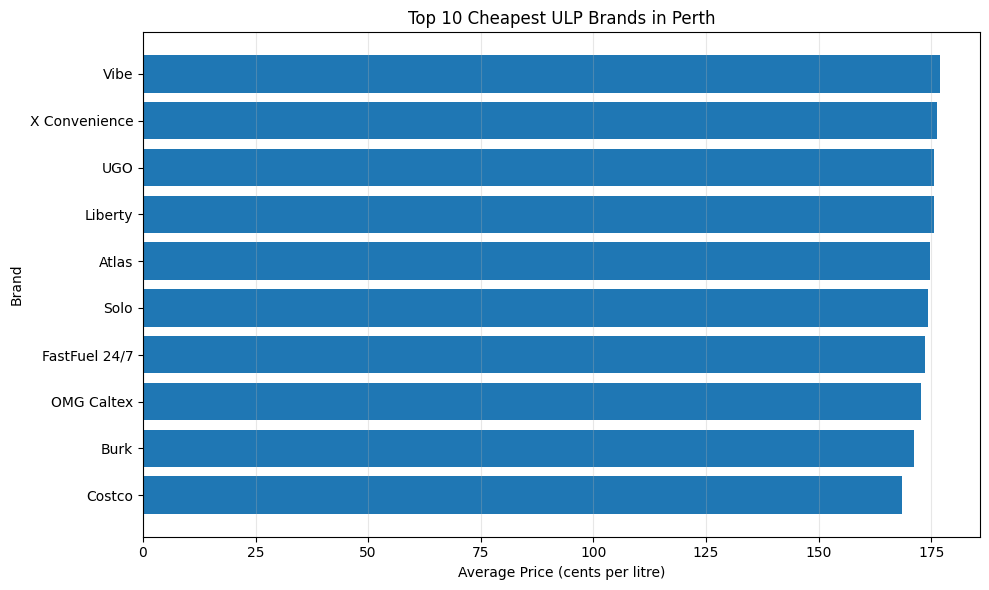

In [158]:
cheapest_brands = brand_price.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    cheapest_brands["brand"],
    cheapest_brands["average_price"]
)

plt.title("Top 10 Cheapest ULP Brands in Perth")
plt.xlabel("Average Price (cents per litre)")
plt.ylabel("Brand")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

### Cheapest and most expensive brands

The brands with the lowest and highest average ULP prices are identified.

In [159]:
cheapest_brand = brand_price.iloc[0]
most_expensive_brand = brand_price.iloc[-1]

print("Cheapest brand:")
print(cheapest_brand)

print("\nMost expensive brand:")
print(most_expensive_brand)

Cheapest brand:
brand                Costco
average_price    168.534254
median_price          156.7
minimum_price         138.7
maximum_price         246.7
observations            362
station_count             2
Name: 8, dtype: object

Most expensive brand:
brand            Independent
average_price       196.0691
median_price           188.0
minimum_price          146.7
maximum_price          269.0
observations            1055
station_count              6
Name: 11, dtype: object


### Estimated saving by choosing a cheaper brand

The potential saving for a 60-litre tank is calculated using the average price difference between the cheapest and most expensive eligible brands.

In [160]:
brand_difference_cpl = (
    most_expensive_brand["average_price"]
    - cheapest_brand["average_price"]
)

brand_saving_60l = (
    brand_difference_cpl * 60
) / 100

print(
    f"Average price difference: "
    f"{brand_difference_cpl:.2f} cents per litre"
)

print(
    f"Estimated saving for a 60L tank: "
    f"${brand_saving_60l:.2f}"
)

Average price difference: 27.53 cents per litre
Estimated saving for a 60L tank: $16.52


## 6. Compare fuel prices by suburb

Average ULP prices are compared across Perth suburbs to identify locations that were generally cheaper or more expensive during the study period.

Suburbs with very few observations are excluded to reduce the risk of misleading comparisons.

In [161]:
suburb_price = (
    df.groupby("suburb", as_index=False)
    .agg(
        average_price=("price_cpl", "mean"),
        median_price=("price_cpl", "median"),
        minimum_price=("price_cpl", "min"),
        maximum_price=("price_cpl", "max"),
        observations=("price_cpl", "size"),
        station_count=("station_id", "nunique"),
        days_observed=("date", "nunique")
    )
)

suburb_price = suburb_price[
    (suburb_price["observations"] >= 100)
    & (suburb_price["station_count"] >= 2)
].sort_values("average_price")

suburb_price.head(10)

,suburb,average_price,median_price,minimum_price,maximum_price,observations,station_count,days_observed
142,OAKFORD,167.174586,157.3,137.3,243.9,362,2,181
18,BECKENHAM,171.971761,159.3,139.3,247.5,301,3,181
149,PERTH AIRPORT,173.823757,166.7,138.7,259.9,362,2,181
34,BULLSBROOK,176.973849,165.0,144.5,259.0,543,3,181
66,FORRESTFIELD,177.248619,169.3,143.7,259.9,905,5,181
103,LANDSDALE,177.572652,165.9,137.3,269.9,724,4,181
72,GOLDEN BAY,177.804420,169.9,144.5,259.9,362,2,181
101,KWINANA BEACH,177.811296,169.5,142.7,269.9,903,5,181
187,WANNEROO,177.943015,169.5,139.2,259.9,1267,7,181
2,ALKIMOS,178.107459,169.9,139.3,263.9,724,4,181


### Cheapest suburbs

The ten suburbs with the lowest average ULP prices are displayed below.

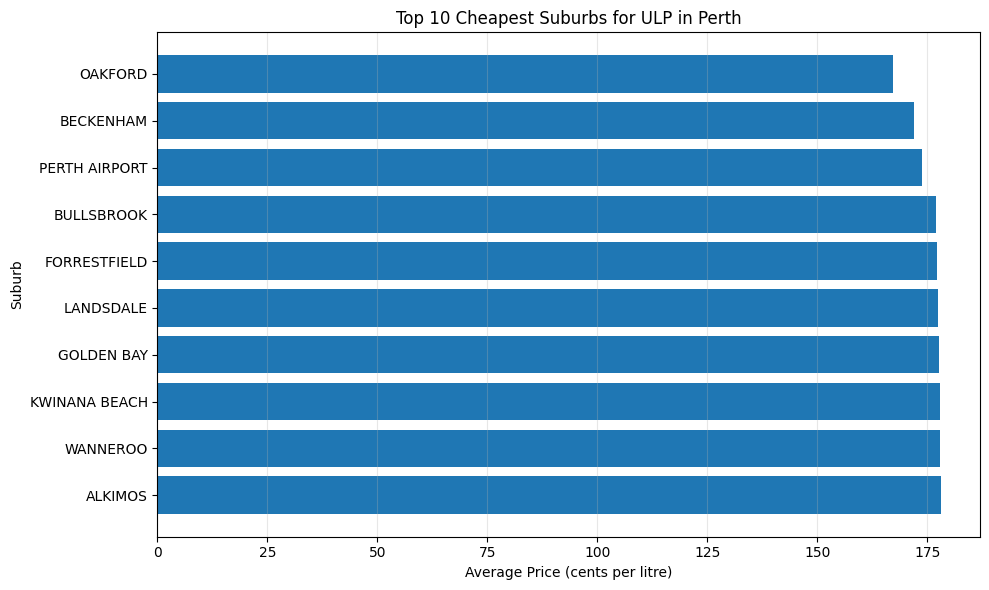

In [162]:
cheapest_suburbs = suburb_price.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    cheapest_suburbs["suburb"],
    cheapest_suburbs["average_price"]
)
plt.gca().invert_yaxis()
plt.title("Top 10 Cheapest Suburbs for ULP in Perth")
plt.xlabel("Average Price (cents per litre)")
plt.ylabel("Suburb")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

### Most expensive suburbs

The ten suburbs with the highest average ULP prices are displayed below.

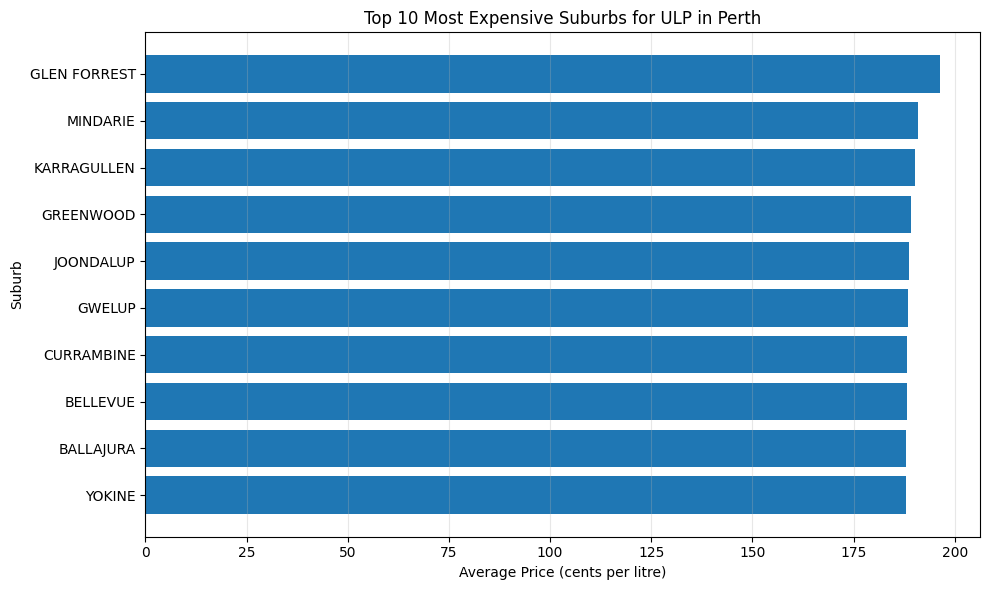

In [163]:
most_expensive_suburbs = (
    suburb_price
    .sort_values("average_price", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    most_expensive_suburbs["suburb"],
    most_expensive_suburbs["average_price"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Most Expensive Suburbs for ULP in Perth")
plt.xlabel("Average Price (cents per litre)")
plt.ylabel("Suburb")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

### Cheapest and most expensive suburbs

The eligible suburbs with the lowest and highest average ULP prices are identified.

In [164]:
cheapest_suburb = suburb_price.iloc[0]
most_expensive_suburb = suburb_price.iloc[-1]

print("Cheapest suburb:")
print(cheapest_suburb)

print("\nMost expensive suburb:")
print(most_expensive_suburb)

Cheapest suburb:
suburb              OAKFORD
average_price    167.174586
median_price          157.3
minimum_price         137.3
maximum_price         243.9
observations            362
station_count             2
days_observed           181
Name: 142, dtype: object

Most expensive suburb:
suburb           GLEN FORREST
average_price      196.425967
median_price            183.9
minimum_price           149.9
maximum_price           269.9
observations              362
station_count               2
days_observed             181
Name: 70, dtype: object


### Estimated saving by choosing a cheaper suburb

The potential saving for a 60-litre tank is estimated using the average price difference between the cheapest and most expensive eligible suburbs. This calculation illustrates the price difference between the lowest and highest eligible groups. It does not account for travel distance, membership requirements, or differences in station availability.

In [165]:
suburb_difference_cpl = (
    most_expensive_suburb["average_price"]
    - cheapest_suburb["average_price"]
)

suburb_saving_60l = (
    suburb_difference_cpl * 60
) / 100

print(
    f"Average price difference: "
    f"{suburb_difference_cpl:.2f} cents per litre"
)

print(
    f"Estimated saving for a 60L tank: "
    f"${suburb_saving_60l:.2f}"
)

Average price difference: 29.25 cents per litre
Estimated saving for a 60L tank: $17.55


## 7. Identify consistently cheap fuel stations

Each station's price is compared with the Perth daily average price.

A negative difference means the station was cheaper than the market average on that day.

In [166]:
station_daily_price = (
    df.groupby(
        [
            "date",
            "station_id",
            "station_name",
            "brand",
            "suburb",
            "address"
        ],
        as_index=False
    )
    .agg(
        price_cpl=("price_cpl", "mean")
    )
)

market_daily_average = (
    station_daily_price.groupby(
        "date",
        as_index=False
    )
    .agg(
        market_average_price=("price_cpl", "mean")
    )
)

station_daily_price = station_daily_price.merge(
    market_daily_average,
    on="date",
    how="left"
)

station_daily_price["difference_from_daily_avg"] = (
    station_daily_price["price_cpl"]
    - station_daily_price["market_average_price"]
)

station_daily_price[
    [
        "date",
        "station_name",
        "suburb",
        "price_cpl",
        "difference_from_daily_avg"
    ]
].head()

,date,station_name,suburb,price_cpl,difference_from_daily_avg
0,2026-01-01,7-Eleven Alkimos,ALKIMOS,169.9,-5.944789
1,2026-01-01,7-Eleven Ascot,ASCOT,179.9,4.055211
2,2026-01-01,7-Eleven Balcatta,BALCATTA,179.9,4.055211
3,2026-01-01,7-Eleven Baldivis,BALDIVIS,179.9,4.055211
4,2026-01-01,7-Eleven Balga,BALGA,179.9,4.055211


### Station performance summary

Fuel stations are summarised using their average price, price consistency, number of observed days, and average difference from the daily Perth market price.

In [167]:
station_summary = (
    station_daily_price.groupby(
        [
            "station_id",
            "station_name",
            "brand",
            "suburb",
            "address"
        ],
        as_index=False
    )
    .agg(
        average_price=("price_cpl", "mean"),
        median_price=("price_cpl", "median"),
        minimum_price=("price_cpl", "min"),
        maximum_price=("price_cpl", "max"),
        price_std=("price_cpl", "std"),
        average_difference_from_market=(
            "difference_from_daily_avg",
            "mean"
        ),
        days_observed=("date", "nunique"),
        observations=("price_cpl", "size")
    )
)

station_summary.head()

,station_id,station_name,brand,suburb,address,average_price,median_price,minimum_price,maximum_price,price_std,average_difference_from_market,days_observed,observations
0,7-eleven alkimos_10 carlsbad prom_alkimos,7-Eleven Alkimos,7-Eleven,ALKIMOS,10 Carlsbad Prom,181.923204,169.9,149.9,259.9,29.375094,-1.945529,181,181
1,7-eleven ascot_194 great eastern hwy_ascot,7-Eleven Ascot,7-Eleven,ASCOT,194 Great Eastern Hwy,185.788398,173.9,147.9,259.9,28.257603,1.919665,181,181
2,7-eleven balcatta_174 balcatta rd_balcatta,7-Eleven Balcatta,7-Eleven,BALCATTA,174 Balcatta Rd,185.280110,173.9,149.9,259.9,28.632003,1.411377,181,181
3,7-eleven baldivis_370 baldivis rd_baldivis,7-Eleven Baldivis,7-Eleven,BALDIVIS,370 Baldivis Rd,184.920994,175.9,149.9,259.9,28.590632,1.052261,181,181
4,7-eleven balga_102 princess rd_balga,7-Eleven Balga,7-Eleven,BALGA,102 Princess Rd,185.456906,173.9,149.9,259.9,28.590451,1.588173,181,181


### Filter stations with sufficient observations

Stations must have price records for at least 70% of the days
in the study period to be included in the consistency
comparison.

In [168]:
selected_day_count = station_daily_price["date"].nunique()

minimum_required_days = max(
    1,
    math.ceil(selected_day_count * 0.7)
)

eligible_stations = station_summary[
    station_summary["days_observed"] >= minimum_required_days
].copy()

print("Days in study period:", selected_day_count)
print("Minimum required days:", minimum_required_days)
print("Eligible stations:", eligible_stations.shape[0])

Days in study period: 181
Minimum required days: 127
Eligible stations: 441


### Stations consistently below the daily market average

Stations are ranked by their average difference from the daily Perth market price. More negative values indicate stronger long-term price competitiveness.

In [169]:
cheapest_stations = (
    eligible_stations
    .sort_values("average_difference_from_market")
    .head(10)
)

cheapest_stations[
    [
        "station_name",
        "brand",
        "suburb",
        "average_price",
        "average_difference_from_market",
        "days_observed",
        "price_std"
    ]
]

,station_name,brand,suburb,average_price,average_difference_from_market,days_observed,price_std
208,Burk Oakford,Burk,OAKFORD,166.642541,-17.226192,181,27.102565
450,Vibe Oakford Truckstop,Vibe,OAKFORD,167.706630,-16.162103,181,27.749612
266,Costco Perth Airport,Costco,PERTH AIRPORT,168.534254,-15.334479,181,28.127392
265,Costco Casuarina,Costco,CASUARINA,168.534254,-15.334479,181,28.155819
295,Liberty Beckenham,Liberty,BECKENHAM,169.514365,-14.354368,181,25.426976
205,Burk Landsdale,Burk,LANDSDALE,169.802762,-14.065971,181,27.525064
109,Atlas Fuel Forrestdale,Atlas,FORRESTDALE,170.768508,-13.100225,181,27.041083
200,Burk Alkimos,Burk,ALKIMOS,170.797238,-13.071496,181,27.961605
201,Burk Bassendean,Burk,BASSENDEAN,170.962983,-12.905750,181,27.726886
452,Vibe Piara Waters,Vibe,PIARA WATERS,170.997238,-12.871496,181,27.619338


### Top 10 consistently cheapest stations

The chart shows the stations with the largest average discount relative to the daily Perth market price.

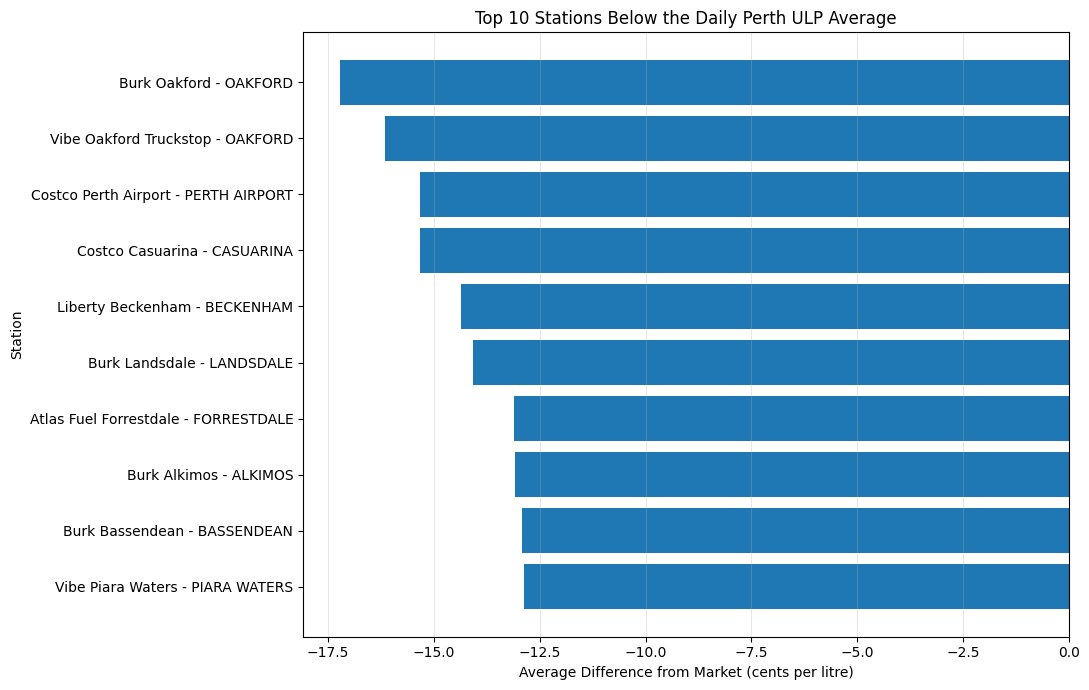

In [170]:
plt.figure(figsize=(11, 7))

plt.barh(
    cheapest_stations["station_name"]
    + " - "
    + cheapest_stations["suburb"],
    cheapest_stations[
        "average_difference_from_market"
    ]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 10 Stations Below the Daily Perth ULP Average"
)
plt.xlabel(
    "Average Difference from Market (cents per litre)"
)
plt.ylabel("Station")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

### Estimated saving at the best-performing station

The average saving for a 60-litre tank is estimated using the station's average discount relative to the daily market price.

In [171]:
best_station = cheapest_stations.iloc[0]

station_discount_cpl = abs(
    best_station["average_difference_from_market"]
)

station_saving_60l = (
    station_discount_cpl * 60
) / 100

print("Best-performing station:")
print(best_station["station_name"])

print("Suburb:")
print(best_station["suburb"])

print(
    f"Average discount: "
    f"{station_discount_cpl:.2f} cents per litre"
)

print(
    f"Estimated saving for a 60L tank: "
    f"${station_saving_60l:.2f}"
)

Best-performing station:
Burk Oakford
Suburb:
OAKFORD
Average discount: 17.23 cents per litre
Estimated saving for a 60L tank: $10.34


### Percentage of days below the market average

For each station, the percentage of observed days where its price was below the Perth daily average is calculated.

In [172]:
station_daily_price["below_daily_average"] = (
    station_daily_price["difference_from_daily_avg"] < 0
)

below_market_rate = (
    station_daily_price.groupby(
        "station_id",
        as_index=False
    )
    .agg(
        below_market_days=(
            "below_daily_average",
            "sum"
        ),
        below_market_days_observed=(
            "date",
            "nunique"
        )
    )
)

below_market_rate["below_market_percentage"] = (
    below_market_rate["below_market_days"]
    / below_market_rate["below_market_days_observed"]
    * 100
)

station_summary = station_summary.merge(
    below_market_rate[
        [
            "station_id",
            "below_market_days",
            "below_market_percentage"
        ]
    ],
    on="station_id",
    how="left"
)

In [173]:
station_summary[
    station_summary["days_observed"] >= minimum_required_days
].sort_values(
    [
        "below_market_percentage",
        "average_difference_from_market"
    ],
    ascending=[False, True]
)[
    [
        "station_name",
        "brand",
        "suburb",
        "below_market_percentage",
        "average_difference_from_market",
        "days_observed"
    ]
].head(10)

,station_name,brand,suburb,below_market_percentage,average_difference_from_market,days_observed
208,Burk Oakford,Burk,OAKFORD,100.0,-17.226192,181
450,Vibe Oakford Truckstop,Vibe,OAKFORD,100.0,-16.162103,181
265,Costco Casuarina,Costco,CASUARINA,100.0,-15.334479,181
266,Costco Perth Airport,Costco,PERTH AIRPORT,100.0,-15.334479,181
205,Burk Landsdale,Burk,LANDSDALE,100.0,-14.065971,181
200,Burk Alkimos,Burk,ALKIMOS,100.0,-13.071496,181
201,Burk Bassendean,Burk,BASSENDEAN,100.0,-12.905750,181
452,Vibe Piara Waters,Vibe,PIARA WATERS,100.0,-12.871496,181
207,Burk Mount Lawley,Burk,MOUNT LAWLEY,100.0,-12.519009,181
206,Burk Malaga,Burk,MALAGA,100.0,-12.237241,181


### Key finding

Several eligible stations remained below the Perth daily ULP
average on every observed day during the study period.

Burk Oakford was the strongest performer, averaging
approximately 17.23 cents per litre below the daily Perth
market average across 181 observed days. This difference is
equivalent to approximately $10.34 for a 60-litre fill.

Burk, Vibe, Costco, and Liberty were strongly represented among
the highest-ranked stations, suggesting that these brands
included several consistently price-competitive locations.